Importing Libraries

In [1]:
import torch
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Dataset Loading

In [3]:
dataset = load_dataset('imdb')

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


Tokenizer

In [5]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Tokenization function

In [6]:
def tokenize(example):
    return tokenizer(
        example['text'],
        padding = 'max_length',
        truncation = True,
        max_length = 256
    )

In [7]:
dataset = dataset.map(tokenize, batched=True)

In [8]:
print(dataset['train'][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Dataset convertion

In [9]:
dataset.set_format(
    type = 'torch',
    columns = ['input_ids', 'attention_mask', 'label']
)

In [10]:
sample = dataset['train'][0]

print(type (sample['input_ids']))
print(sample['input_ids'].shape)

<class 'torch.Tensor'>
torch.Size([256])


Data Loader

In [11]:
train_loader = DataLoader(dataset['train'], batch_size=8, shuffle=True)
test_loader = DataLoader(dataset['test'], batch_size=8)

In [12]:
batch = next(iter(train_loader))

print(batch.keys())
print(batch['input_ids'].shape)

dict_keys(['label', 'input_ids', 'attention_mask'])
torch.Size([8, 256])


Loading Model

In [13]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels =2
)

model.to(device)

print(model)    

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Training

In [16]:
optimizer =AdamW(model.parameters(), lr= 2e-5)

In [18]:
train_losses = []
val_accuracies = []

best_acc = 0
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

  
    model.eval()
    preds = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true_labels.extend(batch['label'].numpy())

    from sklearn.metrics import accuracy_score

    acc = accuracy_score(true_labels, preds)
    val_accuracies.append(acc)

   
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}")

   
    if acc > best_acc:
        best_acc = acc
        model.save_pretrained("best_model")
        tokenizer.save_pretrained("best_model")
        print("Best model saved!")

Epoch 1 | Loss: 0.1362 | Accuracy: 0.9163


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!
Epoch 2 | Loss: 0.0714 | Accuracy: 0.9171


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!
Epoch 3 | Loss: 0.0434 | Accuracy: 0.9180


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!
Epoch 4 | Loss: 0.0298 | Accuracy: 0.9100
Epoch 5 | Loss: 0.0274 | Accuracy: 0.9102
Epoch 6 | Loss: 0.0223 | Accuracy: 0.9149
Epoch 7 | Loss: 0.0206 | Accuracy: 0.9116
Epoch 8 | Loss: 0.0212 | Accuracy: 0.9080
Epoch 9 | Loss: 0.0169 | Accuracy: 0.9164
Epoch 10 | Loss: 0.0144 | Accuracy: 0.9030


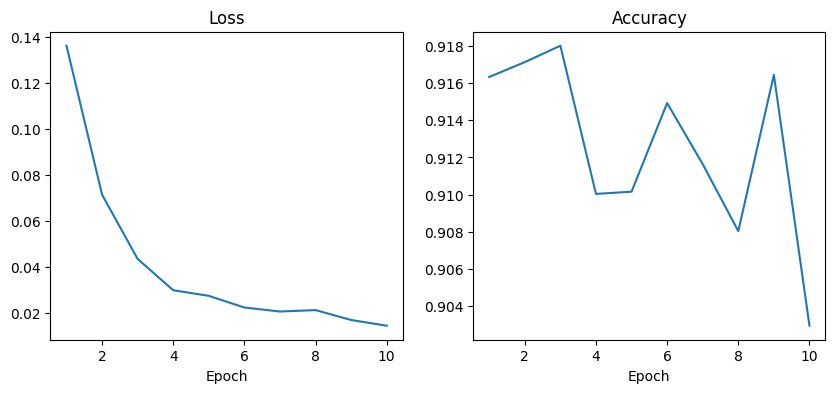

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.plot(epochs, train_losses)
plt.title("Loss")
plt.xlabel("Epoch")


plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies)
plt.title("Accuracy")
plt.xlabel("Epoch")

plt.show()

Loading Best model

In [22]:
model = BertForSequenceClassification.from_pretrained("best_model")
tokenizer = BertTokenizer.from_pretrained("best_model")

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Inference

In [23]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation = True,
        padding = True,
        max_length = 256
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()

    return 'Positive' if pred==1 else "Negative"

In [24]:
predict('A good movie, although some scenes were boring')

'Positive'